In [ ]:
import pandas as pd
import numpy as np

# Load the Ethiopia data
# We use '../data/' because the notebook is inside the 'notebooks' folder
df = pd.read_csv('../data/ethiopia.csv')

# Add the country column as required
df['Country'] = 'Ethiopia'

# Convert YEAR and DOY to a real Date column
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract the month for seasonal analysis
df['Month'] = df['Date'].dt.month

# Preview the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [ ]:
# Replace -999 with NaN so it doesn't break our math [cite: 472]
df.replace(-999, np.nan, inplace=True)

# Check for duplicates [cite: 474]
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")

# Drop duplicates if any were found
df.drop_duplicates(inplace=True)

Found 0 duplicate rows.


In [ ]:
# Replace NASA sentinel values with NaN (Not a Number)
df.replace(-999, np.nan, inplace=True)

# Check for duplicates (A specific requirement in your challenge doc)
print(f"Duplicate rows: {df.duplicated().sum()}")

# Drop them just in case
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Nigeria Data
df = pd.read_csv('../data/nigeria.csv')
df.replace(-999, np.nan, inplace=True)

# 2. Date Processing
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

# 3. HEATMAP (Shows how variables relate)
plt.figure(figsize=(8, 6))
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
sns.heatmap(df[cols].corr(), annot=True, cmap='YlGnBu')
plt.title('Nigeria: Climate Variable Correlations')
plt.show()

# 4. MONTHLY LINE CHART (The one your teammate likely has)
monthly_avg = df.groupby('Month')['T2M'].mean()
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='line', marker='s', color='blue', linewidth=2)
plt.title('Nigeria: Average Monthly Temperature Trend')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [ ]:
from scipy import stats

# Choose a column to check, like T2M (Temperature)
# We use 'omit' to ignore the NaNs we created earlier
df['T2M_zscore'] = np.abs(stats.zscore(df['T2M'], nan_policy='omit'))

# Flag outliers where the Z-score is greater than 3
outliers = df[df['T2M_zscore'] > 3]
print(f"Number of temperature outliers found: {len(outliers)}")

Number of temperature outliers found: 3


In [ ]:
# Calculate the percentage of missing values
missing_pct = (df.isna().sum() / len(df)) * 100

print("--- Missing Value Report ---")
print(missing_pct)

# Check for the >5% threshold required by your task
high_missing = missing_pct[missing_pct > 5]
if not high_missing.empty:
    print(f"\n⚠️ WARNING: Columns with >5% missing values: {list(high_missing.index)}")
else:
    print("\n✅ All columns have less than 5% missing values.")

--- Missing Value Report ---
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
T2M_zscore     0.0
dtype: float64

✅ All columns have less than 5% missing values.


In [ ]:
# This generates the statistics for all numeric columns (T2M, PRECTOTCORR, etc.)
summary_stats = df.describe()

# This displays the table in your notebook
summary_stats

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,T2M_zscore
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564,0.797988
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000,0.000790
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000,0.311673
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000,0.669979
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000,1.186361
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000,3.181810
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046,0.602747


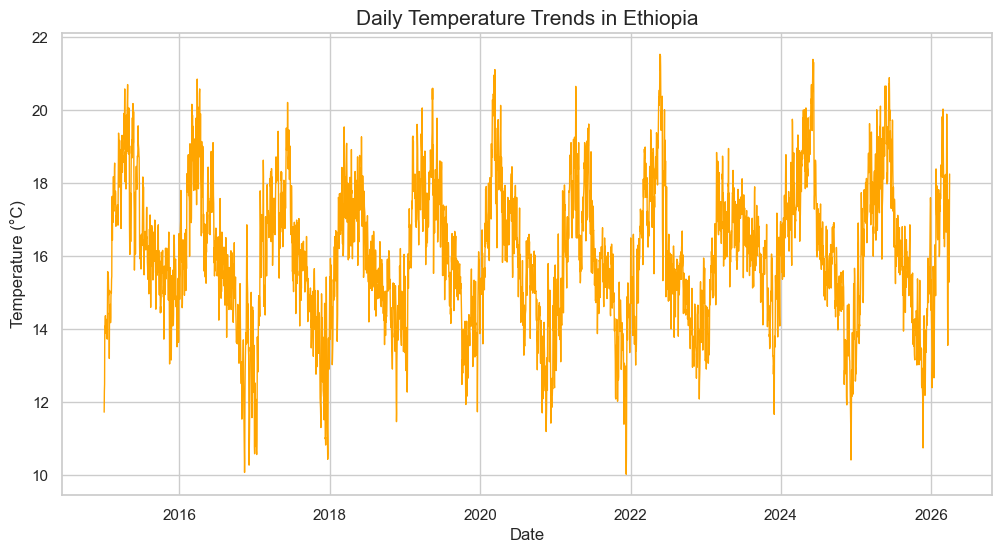

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 2: MAKE IT LOOK PRETTY ---
sns.set_theme(style="whitegrid")

# --- STEP 3: DRAW THE GRAPH ---
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['T2M'], color='orange', linewidth=1)

# --- STEP 4: ADD THE LABELS ---
plt.title('Daily Temperature Trends in Ethiopia', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

# --- STEP 5: SHOW THE RESULT ---
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. LOAD THE DATA (Ensuring 'df' is defined right here)
df = pd.read_csv('../data/ethiopia.csv')

# 2. BASIC CLEANING (Replacing NASA's -999)
df.replace(-999, np.nan, inplace=True)

# 3. DEFINE COLUMNS
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

print("--- Outlier Report (Z-Score > 3) ---")

# 4. CALCULATE OUTLIERS
for col in cols:
    # Calculate Z-score while ignoring empty cells
    z = np.abs(stats.zscore(df[col], nan_policy='omit'))
    outliers = (z > 3).sum()
    print(f"{col}: Found {outliers} outliers")

# 5. FORWARD FILL & EXPORT
df[cols] = df[cols].ffill()
df.to_csv('../data/ethiopia_clean.csv', index=False)

print("\n✅ DONE! 'ethiopia_clean.csv' is now in your data folder.")

--- Outlier Report (Z-Score > 3) ---
T2M: Found 3 outliers
T2M_MAX: Found 0 outliers
T2M_MIN: Found 18 outliers
PRECTOTCORR: Found 95 outliers
RH2M: Found 13 outliers
WS2M: Found 3 outliers
WS2M_MAX: Found 5 outliers

✅ DONE! 'ethiopia_clean.csv' is now in your data folder.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

countries = ['kenya', 'nigeria', 'sudan', 'tanzania']
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

for country in countries:
    print(f"\n--- Processing {country.upper()} ---")
    
    # Load
    temp_df = pd.read_csv(f'../data/{country}.csv')
    
    # Clean
    temp_df.replace(-999, np.nan, inplace=True)
    
    # Outliers
    for col in cols:
        z = np.abs(stats.zscore(temp_df[col], nan_policy='omit'))
        print(f"{col} Outliers: {(z > 3).sum()}")
    
    # Fill & Export
    temp_df[cols] = temp_df[cols].ffill()
    temp_df.to_csv(f'../data/{country}_clean.csv', index=False)
    print(f"✅ {country}_clean.csv created successfully!")


--- Processing KENYA ---
T2M Outliers: 8
T2M_MAX Outliers: 3
T2M_MIN Outliers: 9
PRECTOTCORR Outliers: 92
RH2M Outliers: 6
WS2M Outliers: 0
WS2M_MAX Outliers: 6
✅ kenya_clean.csv created successfully!

--- Processing NIGERIA ---
T2M Outliers: 10
T2M_MAX Outliers: 1
T2M_MIN Outliers: 68
PRECTOTCORR Outliers: 75
RH2M Outliers: 128
WS2M Outliers: 5
WS2M_MAX Outliers: 10
✅ nigeria_clean.csv created successfully!

--- Processing SUDAN ---
T2M Outliers: 3
T2M_MAX Outliers: 6
T2M_MIN Outliers: 1
PRECTOTCORR Outliers: 71
RH2M Outliers: 3
WS2M Outliers: 4
WS2M_MAX Outliers: 3
✅ sudan_clean.csv created successfully!

--- Processing TANZANIA ---
T2M Outliers: 1
T2M_MAX Outliers: 2
T2M_MIN Outliers: 4
PRECTOTCORR Outliers: 81
RH2M Outliers: 2
WS2M Outliers: 8
WS2M_MAX Outliers: 4
✅ tanzania_clean.csv created successfully!
